In [19]:
import pandas as pd

df = pd.read_csv("/Users/dishasanthosh/Library/CloudStorage/OneDrive-Personal/Uni/Projects/retail-ds-project/data/clean_transactions.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.shape


(397884, 9)

In [20]:
snapshot_date = df['InvoiceDate'].max()
print(snapshot_date)


2011-12-09 12:50:00


In [21]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']


In [22]:
rfm.shape


(4338, 4)

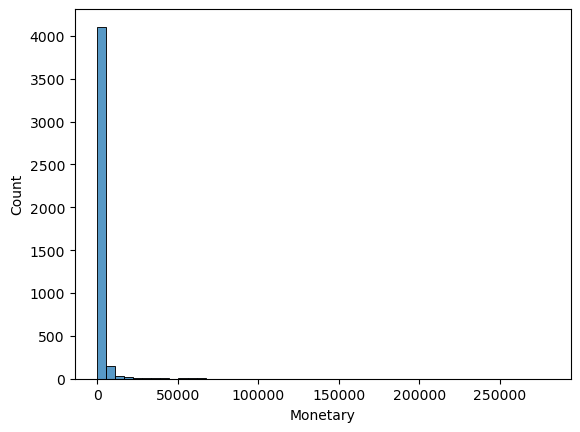

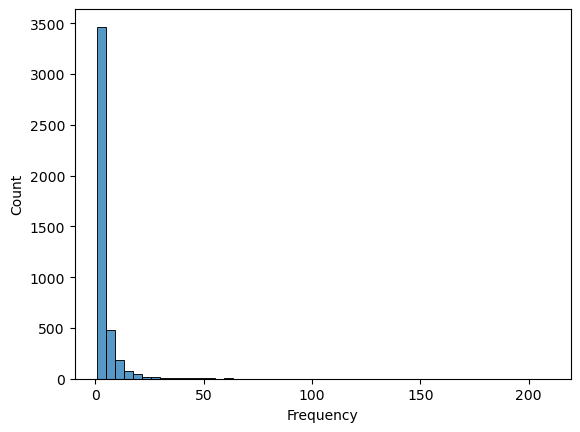

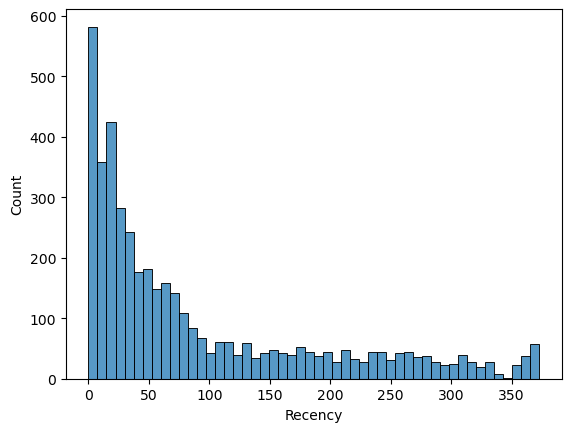

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(rfm['Monetary'], bins=50)
plt.show()

sns.histplot(rfm['Frequency'], bins=50)
plt.show()

sns.histplot(rfm['Recency'], bins=50)
plt.show()


In [24]:
rfm.to_csv("/Users/dishasanthosh/Library/CloudStorage/OneDrive-Personal/Uni/Projects/retail-ds-project/data/customer_rfm.csv", index=False)